# Shannon Entropy Strategy - unified Colab notebook

This notebook follows the required final-project structure and uses only the prepared CSV data from 2001-01-31 through 2024-12-31. No post-2024 continuation is used. The dataset-building code is excluded; the notebook starts from the files in `data/`.


## 1. Imports, constants, and paths

`DATA_PATH` is a text variable as required by the project instructions. The constants define the rolling window, entropy bins, quantile window, risk aversion, and the regime-to-cap policy.


In [1]:
from bisect import bisect_left, insort
from collections import Counter, deque
from pathlib import Path
import csv
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy.optimize import minimize


# Folders required by the project instructions
DATA_PATH = "data"
OUTPUT_PATH = "outputs"

# Core model hyperparameters
ROLLING_WINDOW = 126
ENTROPY_BINS = 8
QUANTILE_WINDOW = 504
RISK_AVERSION = 4.0

# Regime-to-constraint policy
REGIME_TO_MAX_WEIGHT = {
    "Bullish": 0.30,
    "Neutral": 0.15,
    "Bearish": 0.10,
}

# Plotting and reporting conventions
MARKET_PHASE_ORDER = ["Bullish", "Neutral", "Bearish"]
MARKET_PHASE_COLORS = {
    "Bullish": "#2ca25f",
    "Neutral": "#969696",
    "Bearish": "#de2d26",
}

# Stress periods used in the report
CRISIS_WINDOWS = [
    ("Global financial crisis", "2007-10-09", "2009-03-09"),
    ("Euro debt and US downgrade", "2011-07-01", "2011-12-31"),
    ("COVID crash", "2020-02-19", "2020-04-30"),
    ("Inflation and rates bear market", "2022-01-03", "2022-12-30"),
]


## 2. CSV parsing helpers

These functions convert prepared CSV fields into numerical prices and then into simple returns. Missing values stay as `None` so the rolling states can decide when a window is ready.


In [2]:
def parse_float(value):
    """Convert a CSV field to float and use None for missing or invalid values."""
    if value is None:
        return None

    text = str(value).strip()
    if text == "":
        return None

    try:
        return float(text)
    except ValueError:
        return None


def simple_return(price_today, price_yesterday):
    """Compute a simple one-period return from two consecutive prices."""
    if price_today is None or price_yesterday is None:
        return None

    if price_yesterday == 0:
        return None

    return price_today / price_yesterday - 1.0


## 3. Custom rolling classes and data structures

The main custom structures are `RollingStockState`, `MonotonicQueue`, `RollingQuantile`, and `ActiveUniverse`. They are the algorithmic core of the project: rolling state by stock, amortized rolling min/max, rolling entropy quantiles, and daily top-10 lookup.

Complexity summary: state updates cost `O(N)` per day, rolling min/max are `O(1)` amortized, entropy is `O(W+B)` per active stock, quantile update is `O(Q)`, and quantile lookup is `O(1)`.


In [3]:
class MonotonicQueue:
    """
    Candidate queue for rolling min or max.

    push   -> O(1) amortized
    expire -> O(1) amortized
    top    -> O(1)
    """

    def __init__(self, mode):
        # Initialize the queue as min-queue or max-queue. Cost: O(1)
        self.mode = mode
        self.q = deque()

    def push(self, time_index, value):
        # Insert a new value and remove dominated candidates. Cost: O(1) amortized
        if value is None:
            return

        if self.mode == "min":
            while len(self.q) > 0 and self.q[-1][1] > value:
                self.q.pop()
        else:
            while len(self.q) > 0 and self.q[-1][1] < value:
                self.q.pop()

        self.q.append((time_index, value))

    def expire(self, first_valid_index):
        # Remove candidates outside the rolling window. Cost: O(1) amortized
        while len(self.q) > 0 and self.q[0][0] < first_valid_index:
            self.q.popleft()

    def top(self):
        # Return current rolling min/max. Cost: O(1)
        if len(self.q) == 0:
            return None
        return self.q[0][1]

    def as_list(self):
        # Convert internal queue to list for inspection. Cost: O(m)
        output = []
        for item in self.q:
            output.append(item)
        return output


class RollingStockState:
    """
    Rolling state for one stock.

    Structures:
        buffer: last W returns
        sum_x: running sum
        sum_x2: running sum of squares
        min_q / max_q: monotonic queues
    """

    def __init__(self, window):
        # Initialize the rolling state for one stock. Cost: O(1)
        self.W = window
        self.buffer = deque()
        self.sum_x = 0.0
        self.sum_x2 = 0.0
        self.count = 0
        self.time_index = -1
        self.min_q = MonotonicQueue("min")
        self.max_q = MonotonicQueue("max")

    def push(self, value):
        # Add a new return and remove the oldest one if the window is full. Cost: O(1) amortized
        self.time_index = self.time_index + 1

        if len(self.buffer) == self.W:
            old_value = self.buffer.popleft()
            if old_value is not None:
                self.sum_x = self.sum_x - old_value
                self.sum_x2 = self.sum_x2 - old_value * old_value
                self.count = self.count - 1

        self.buffer.append(value)

        if value is not None:
            self.sum_x = self.sum_x + value
            self.sum_x2 = self.sum_x2 + value * value
            self.count = self.count + 1
            self.min_q.push(self.time_index, value)
            self.max_q.push(self.time_index, value)

        first_valid_index = self.time_index - self.W + 1
        self.min_q.expire(first_valid_index)
        self.max_q.expire(first_valid_index)

    def ready(self):
        # Check whether the rolling window has W valid returns. Cost: O(1)
        return len(self.buffer) == self.W and self.count == self.W

    def rolling_mean(self):
        # Return the rolling mean using the running sum. Cost: O(1)
        if not self.ready():
            return None
        return self.sum_x / self.W

    def rolling_variance(self):
        # Return the rolling sample variance using running sums. Cost: O(1)
        if not self.ready():
            return None

        numerator = self.sum_x2 - (self.sum_x * self.sum_x) / self.W
        variance = numerator / (self.W - 1)

        if variance < 0:
            variance = 0.0

        return variance

    def rolling_volatility(self, annualized=False):
        # Return rolling volatility, optionally annualized. Cost: O(1)
        variance = self.rolling_variance()

        if variance is None:
            return None

        volatility = math.sqrt(variance)

        if annualized:
            volatility = volatility * math.sqrt(252.0)

        return volatility

    def rolling_min(self):
        # Return the rolling minimum from the monotonic queue. Cost: O(1)
        if not self.ready():
            return None
        return self.min_q.top()

    def rolling_max(self):
        # Return the rolling maximum from the monotonic queue. Cost: O(1)
        if not self.ready():
            return None
        return self.max_q.top()

    def rolling_entropy(self, bins):
        # Compute normalized Shannon entropy from adaptive histogram bins. Cost: O(W + B)
        if not self.ready():
            return None

        lower = self.rolling_min()
        upper = self.rolling_max()

        if lower == upper:
            return 0.0

        counts = [0] * bins
        width = (upper - lower) / bins

        for value in self.buffer:
            if value == upper:
                bin_index = bins - 1
            else:
                bin_index = int((value - lower) / width)

                if bin_index < 0:
                    bin_index = 0

                if bin_index >= bins:
                    bin_index = bins - 1

            counts[bin_index] = counts[bin_index] + 1

        entropy = 0.0

        for count in counts:
            if count > 0:
                probability = count / self.W
                entropy = entropy - probability * math.log2(probability)

        return entropy / math.log2(bins)

    def values_as_list(self):
        # Return the current rolling window as a list. Cost: O(W)
        values = []

        for value in self.buffer:
            values.append(value)

        return values

class RollingQuantile:
    """
    Exact rolling quantile using:

    buffer        -> time order
    sorted_values -> value order

    push     -> O(Q)
    quantile -> O(1)
    """

    def __init__(self, window):
        # Initialize the rolling quantile window. Cost: O(1)
        self.W = window
        self.buffer = deque()
        self.sorted_values = []

    def push(self, value):
        # Add a value and remove the oldest one if the window is full. Cost: O(Q)
        if value is None:
            return

        if len(self.buffer) == self.W:
            old_value = self.buffer.popleft()
            position = bisect_left(self.sorted_values, old_value)
            self.sorted_values.pop(position)

        self.buffer.append(value)
        insort(self.sorted_values, value)

    def ready(self):
        # Check whether the quantile window is full. Cost: O(1)
        return len(self.buffer) == self.W

    def quantile(self, q):
        # Return the q-th rolling quantile by interpolation. Cost: O(1)
        if not self.ready():
            return None

        n = len(self.sorted_values)
        raw_position = q * (n - 1)
        low_position = int(math.floor(raw_position))
        high_position = int(math.ceil(raw_position))

        if low_position == high_position:
            return self.sorted_values[low_position]

        weight = raw_position - low_position
        low_value = self.sorted_values[low_position]
        high_value = self.sorted_values[high_position]

        return (1.0 - weight) * low_value + weight * high_value


class ActiveUniverse:
    """
    date -> active top-10 integer stock indices.

    Lookup is O(1) average.
    """

    def __init__(self):
        # Initialize the dictionary date -> active indices. Cost: O(1)
        self.by_date = {}

    def load_from_csv(self, path):
        # Load the daily top-10 universe from CSV. Cost: O(TK), where T: number of dates in the csv
        with open(path, newline="", encoding="utf-8") as file:
            reader = csv.DictReader(file)

            for row in reader:
                indices = []
                parts = str(row["Top 10 stock indices"]).split(",")

                for part in parts:
                    text = part.strip()

                    if text != "":
                        indices.append(int(text))

                self.by_date[row["Date"]] = indices

    def get(self, date):
        # Return the active stock indices for one date. Cost: O(1) average
        return self.by_date.get(date, [])

## 4. Data loading and return construction

The prepared input files are `dataset.csv`, `top10_dictionary.csv`, and `ticker_mapping.csv`. They are derived locally from `Equity_Data_Eikon.h5`; Colab does not need to load the HDF5 source. The dataset contains 36 stock series and ends on 2024-12-31. For every trading day `t`, `top10_dictionary.csv` ranks company-level Eikon market capitalizations available by `t-1`, after filtering incomplete Eikon rows and restricting names to the latest S&P 500 constituent set. It is therefore a genuinely daily, causal ranking rather than a monthly list forward-filled to daily dates. The stock matrix is indexed by integer positions, avoiding repeated ticker-string searches inside the daily loop.


In [4]:
def load_prices(path):
    """Load dates, stock price indices, tickers, and the S&P 500 column from dataset.csv. Cost: O(TN)"""
    with open(path, newline="", encoding="utf-8") as file:
        reader = csv.reader(file)
        header = next(reader)

        stock_positions = []
        tickers = []
        sp500_position = None

        for column_index in range(len(header)):
            column_name = header[column_index]
            if column_name == "SP500":
                sp500_position = column_index
            elif column_name != "Date":
                stock_positions.append(column_index)
                tickers.append(column_name)

        dates = []
        prices = []
        sp500_prices = []

        for row in reader:
            dates.append(row[0])

            price_row = []
            for column_index in stock_positions:
                price_row.append(parse_float(row[column_index]))
            prices.append(price_row)

            sp500_prices.append(parse_float(row[sp500_position]))

    return dates, tickers, prices, sp500_prices


def compute_returns(prices):
    """Transform a rectangular price matrix into daily simple returns. Cost: O(TN)"""
    returns = []
    previous_prices = None

    for row_index in range(len(prices)):
        current_prices = prices[row_index]
        return_row = []

        if previous_prices is None:
            for j in range(len(current_prices)):
                return_row.append(None)
        else:
            for j in range(len(current_prices)):
                return_row.append(simple_return(current_prices[j], previous_prices[j]))

        returns.append(return_row)
        previous_prices = current_prices

    return returns


def compute_sp500_returns(sp500_prices):
    """Compute daily simple returns for the S&P 500 benchmark series. Cost: O(T)"""
    returns = []
    previous_price = None

    for price in sp500_prices:
        returns.append(simple_return(price, previous_price))
        previous_price = price

    return returns


In [5]:
try:
    from IPython.display import display, Image
except ImportError:
    def display(value):
        print(value)

    class Image:
        def __init__(self, filename=None, width=None):
            self.filename = filename
            self.width = width

        def __repr__(self):
            return f"Image(filename={self.filename}, width={self.width})"

base_dir = Path.cwd()
data_dir = Path(DATA_PATH)
output_dir = Path(OUTPUT_PATH)

if not data_dir.is_absolute():
    data_dir = base_dir / data_dir
if not output_dir.is_absolute():
    output_dir = base_dir / output_dir

# Corrected paths based on file system and available files
dataset_path = data_dir / "dataset.csv"
top10_path = data_dir / "top10_dictionary.csv"
ticker_mapping_path = data_dir / "ticker_mapping.csv"


print("Dataset path:", dataset_path)
print("Top-10 path:", top10_path)
print("Output path:", output_dir)

display(pd.read_csv(dataset_path).head(3))
display(pd.read_csv(top10_path).head(3))

Dataset path: C:\Users\salvm\Desktop\GitHub\Entropy\FINALE\data\dataset.csv
Top-10 path: C:\Users\salvm\Desktop\GitHub\Entropy\FINALE\data\top10_dictionary.csv
Output path: C:\Users\salvm\Desktop\GitHub\Entropy\FINALE\outputs


,Date,SP500,AAPL,AIG,AMZN,AVGO,BAC,BRK-B,C,CSCO,...,TWX,UNH,V,WFC,WMT,XOM,HD,MA,ORCL,VZ
0,2001-01-31,100.000000,100.000000,100.000000,100.000000,NaN,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,NaN,100.000000,100.000000,100.000000,100.000000,NaN,100.000000,100.000000
1,2001-02-01,100.555044,97.687861,100.611621,93.862816,NaN,98.996656,102.222222,100.500268,102.170284,...,94.805936,100.585003,NaN,97.845079,98.063380,99.215686,100.933610,NaN,103.218884,100.090992
2,2001-02-02,98.798241,95.375723,101.611386,83.032491,NaN,99.591230,103.644444,99.336034,94.824708,...,90.924658,108.314129,NaN,97.534459,96.408451,98.621509,97.282158,NaN,95.278970,94.631483


,Date,Top 10 tickers,Top 10 stock indices
0,2001-01-31,"GE, MSFT, C, XOM, PFE, CSCO, INTC, WMT, TWX, IBM","9, 20, 6, 31, 22, 7, 12, 30, 26, 11"
1,2001-02-01,"GE, MSFT, C, XOM, PFE, CSCO, WMT, INTC, TWX, AIG","9, 20, 6, 31, 22, 7, 30, 12, 26, 1"
2,2001-02-02,"GE, MSFT, C, XOM, PFE, CSCO, INTC, WMT, TWX, IBM","9, 20, 6, 31, 22, 7, 12, 30, 26, 11"


In [6]:
dates, tickers, prices, sp500_prices = load_prices(dataset_path)
stock_returns = compute_returns(prices)
sp500_returns = compute_sp500_returns(sp500_prices)

print("Dataset period:", dates[0], "to", dates[-1])
print("Trading dates:", len(dates))
print("Stock columns:", len(tickers))
print("First five tickers:", tickers[:5])
print("First available S&P 500 returns:", [value for value in sp500_returns[:5]])


Dataset period: 2001-01-31 to 2024-12-31
Trading dates: 6013
Stock columns: 36
First five tickers: ['AAPL', 'AIG', 'AMZN', 'AVGO', 'BAC']
First available S&P 500 returns: [None, 0.005550437578, -0.017471056461687562, 0.0036132580682513016, -0.001464208162530234]


## 5. Covariance and SLSQP wrapper

Covariance is computed from the current rolling buffers of the active stocks. Building the active W × K return block costs `O(WK)`, and computing the sample covariance matrix costs `O(WK²)`. A manual nested-loop implementation would have the same asymptotic cost, so Pandas is used here only as a numerical convenience.

SLSQP is used as an external continuous constrained optimizer for the final mean-variance allocation step in Bullish and Neutral regimes. The algorithmic contribution of the project is not the implementation of SLSQP, but the causal rolling procedure that builds the active universe, computes entropy, classifies the regime, and maps the regime into portfolio constraints.


In [7]:
def covariance_from_states(states, active_indices):
    """Build the sample covariance matrix from the rolling buffers of active names. Cost: O(WK^2)."""
    data = {}

    for j in active_indices:
        data[str(j)] = states[j].values_as_list()

    return pd.DataFrame(data).cov().values


def solve_mean_variance_slsqp(mu, covariance, cap, risk_aversion):
    """Solve the long-only capped mean-variance problem with SLSQP. Cost: external solver cost"""
    n = len(mu)
    lower_bounds = np.zeros(n)
    upper_bounds = np.full(n, cap)
    x0 = np.full(n, 1.0 / n)
    covariance = 0.5 * (covariance + covariance.T) + np.eye(n) * 1e-8

    def objective(w):
      # Mean-variance objective. Cost: O(K^2)
        return 0.5 * risk_aversion * float(w @ covariance @ w) - float(mu @ w)

    def gradient(w):
       # Analytical gradient of the objective. Cost: O(K^2)
        return risk_aversion * (covariance @ w) - mu

    constraint = {
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1.0,
        "jac": lambda w: np.ones_like(w),
    }

    result = minimize(
        objective,
        x0,
        method="SLSQP",
        jac=gradient,
        bounds=list(zip(lower_bounds, upper_bounds)),
        constraints=[constraint],
        options={"ftol": 1e-10, "maxiter": 120, "disp": False},
    )

    if result.success:
        return result.x, True, result.message

    return x0, False, result.message


## 6. Toy examples

The entropy toy example is solved with the custom rolling state and shows how normalized Shannon entropy is computed from histogram bin counts.

The mini-allocation toy example uses five stocks and two artificial entropy states to illustrate the regime-to-weight pipeline. State 1 is classified as Bullish and uses a 60% cap, State 2 is classified as Neutral and uses a 30% cap, while the Bearish reference allocation is equal weight at 20% per stock.

In [8]:
def build_toy_series(seed=42, observations=60):
    """Generate three synthetic return series used to explain normalized entropy."""
    rng = random.Random(seed)
    structured_trend = []
    two_state_regime = []
    noisy_regime = []

    for i in range(observations):
        x = -0.006 + 0.012 * i / (observations - 1)
        x = x + rng.uniform(-0.0003, 0.0003)
        structured_trend.append(x)

        if rng.random() < 0.5:
            two_state_regime.append(-0.02)
        else:
            two_state_regime.append(0.02)

        noisy_regime.append(rng.gauss(0.0, 0.012))

    return {
        "structured_trend": structured_trend,
        "two_state_regime": two_state_regime,
        "noisy_regime": noisy_regime,
    }


def manual_histogram(values, bins):
    """Count observations in equally spaced bins using the same rule as rolling_entropy. Cost: O(W+B)."""
    lower = min(values)
    upper = max(values)
    counts = [0] * bins

    if lower == upper:
        counts[0] = len(values)
        return counts

    width = (upper - lower) / bins

    for value in values:
        if value == upper:
            bin_index = bins - 1
        else:
            bin_index = int((value - lower) / width)

        counts[bin_index] += 1

    return counts


def prepare_toy_output_dirs(output_dir):
    """Create output folders used by the toy examples. Cost: O(1)."""
    output_dir = Path(output_dir)
    figure_dir = output_dir / "figures"
    figure_dir.mkdir(parents=True, exist_ok=True)
    return output_dir, figure_dir


def entropy_with_state(values, bins):
    """Compute entropy using the same RollingStockState used in the full backtest. Cost: O(W+B)."""
    state = RollingStockState(window=len(values))

    for value in values:
        state.push(float(value))

    return state.rolling_entropy(bins)


def run_toy_example(output_dir, bins=ENTROPY_BINS):
    """Run the synthetic entropy example and save its table."""
    output_dir, figure_dir = prepare_toy_output_dirs(output_dir)
    series_by_name = build_toy_series()

    rows = []

    for name, values in series_by_name.items():
        entropy = entropy_with_state(values, bins)
        counts = manual_histogram(values, bins)

        rows.append({
            "Example": name,
            "Observations": len(values),
            "Bins": bins,
            "NormalizedEntropy": entropy,
            "OrderScore": 1.0 - entropy,
            "MeanReturn": sum(values) / len(values),
            "BinCounts": str(counts),
        })

    toy = pd.DataFrame(rows)
    toy.to_csv(output_dir / "toy_entropy_results.csv", index=False)

    return toy, series_by_name


def toy_cap_for_phase(phase, n):
    """Return the toy cap as a multiple of the equal-weight allocation. Cost: O(1)."""
    equal_weight = 1.0 / n

    if phase == "Bullish":
        return 3.0 * equal_weight

    if phase == "Neutral":
        return 1.5 * equal_weight

    return equal_weight


def clean_weights(weights, tolerance=1e-10):
    """Remove numerical dust from SLSQP weights and preserve the budget constraint. Cost: O(K)."""
    weights = np.array(weights, dtype=float)
    weights[np.abs(weights) < tolerance] = 0.0
    total = weights.sum()

    if total != 0.0:
        weights = weights / total

    return weights


def classify_phase(average_entropy, q_low, q_high):
    """Classify the toy state using the same threshold logic as the full strategy. Cost: O(1)."""
    if average_entropy <= q_low:
        return "Bullish"

    if average_entropy >= q_high:
        return "Bearish"

    return "Neutral"

def run_toy_allocation_example(output_dir):
    """Run the five-stock two-state mini-allocation and save its tables."""
    output_dir, figure_dir = prepare_toy_output_dirs(output_dir)

    returns_percent = {
        "A": [0.6, 0.8, 0.5, 0.7, 0.9, 0.6, 0.8, 0.7],
        "B": [2.0, -1.8, 1.5, -2.2, 0.3, 1.9, -1.0, 0.8],
        "C": [1.2, -0.3, 0.9, 1.5, -0.6, 1.1, 0.4, 0.8],
        "D": [-0.2, -0.5, 0.1, -0.4, -0.3, 0.0, -0.6, 0.2],
        "E": [0.3, 0.4, 0.2, 0.5, 0.4, 0.3, 0.4, 0.3],
    }

    names = list(returns_percent.keys())
    n = len(names)

    returns = np.array([
        [value / 100.0 for value in returns_percent[name]]
        for name in names
    ], dtype=float)

    # Compute expected returns and covariance. Cost: O(WK^2)
    means = returns.mean(axis=1)
    covariance = np.cov(returns)
    covariance = 0.5 * (covariance + covariance.T) + np.eye(n) * 1e-8

    # Two toy entropy states: one Bullish and one Neutral.
    regime_states = pd.DataFrame([
        {
            "State": "State 1",
            "AverageEntropy": 0.430,
            "QLow": 0.500,
            "QHigh": 0.720,
        },
        {
            "State": "State 2",
            "AverageEntropy": 0.580,
            "QLow": 0.470,
            "QHigh": 0.690,
        },
    ])

    weight_columns = {}
    long_rows = []

    # Solve the allocation separately for each toy state.
    for row_index, row in regime_states.iterrows():
        phase = classify_phase(row["AverageEntropy"], row["QLow"], row["QHigh"])
        cap = toy_cap_for_phase(phase, n)

        if phase == "Bearish":
            weights = np.full(n, 1.0 / n)
            solver_success = True
            solver_message = "Bearish phase: uniform allocation; optimizer skipped."
        else:
            weights, solver_success, solver_message = solve_mean_variance_slsqp(
                mu=means,
                covariance=covariance,
                cap=cap,
                risk_aversion=RISK_AVERSION,
            )
            weights = clean_weights(weights)

        regime_states.loc[regime_states["State"] == row["State"], "Phase"] = phase
        regime_states.loc[regime_states["State"] == row["State"], "Cap"] = cap
        weight_columns[f"{row['State']}Weight"] = weights

        for local_index, name in enumerate(names):
            long_rows.append({
                "State": row["State"],
                "Stock": name,
                "Phase": phase,
                "Cap": cap,
                "RollingMean": means[local_index],
                "Weight": weights[local_index],
                "SolverSuccess": solver_success,
                "SolverMessage": str(solver_message),
            })

    bearish_equal_weight = np.full(n, 1.0 / n)

    toy_allocation = pd.DataFrame({
        "Stock": names,
        "RollingMean": means,
        "BullishStateWeight": weight_columns["State 1Weight"],
        "NeutralStateWeight": weight_columns["State 2Weight"],
        "BearishEqualWeight": bearish_equal_weight,
    })

    toy_allocation.to_csv(output_dir / "toy_allocation_results.csv", index=False)
    pd.DataFrame(long_rows).to_csv(output_dir / "toy_allocation_weights_long.csv", index=False)
    regime_states.to_csv(output_dir / "toy_allocation_regime_states.csv", index=False)

    pd.DataFrame(
        covariance * 10000.0,
        index=names,
        columns=names,
    ).to_csv(output_dir / "toy_allocation_covariance_x10000.csv")

    toy_data = {
        "names": names,
        "means": means,
        "regime_states": regime_states,
        "bullish_weights": weight_columns["State 1Weight"],
        "neutral_weights": weight_columns["State 2Weight"],
        "bearish_weights": bearish_equal_weight,
    }

    return toy_allocation, toy_data

In [9]:
def plot_toy_entropy_example(series_by_name, output_dir, bins=ENTROPY_BINS):
    """Save Figure 1: toy entropy bin counts."""
    output_dir, figure_dir = prepare_toy_output_dirs(output_dir)
    x_positions = list(range(1, bins + 1))

    plt.figure(figsize=(8, 4.8))

    for name, values in series_by_name.items():
        plt.plot(
            x_positions,
            manual_histogram(values, bins),
            marker="o",
            label=name,
        )

    plt.title("Toy entropy example - bin counts")
    plt.xlabel("Bin number")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.savefig(figure_dir / "figure_01_toy_entropy_example.png", dpi=160)
    plt.close()


def plot_toy_allocation_example(toy_data, output_dir):
    """Save Figure 2: two-state toy allocation and regime-dependent weights."""
    output_dir, figure_dir = prepare_toy_output_dirs(output_dir)

    names = toy_data["names"]
    regime_states = toy_data["regime_states"]
    bullish_weights = toy_data["bullish_weights"]
    neutral_weights = toy_data["neutral_weights"]
    bearish_weights = toy_data["bearish_weights"]

    x_stages = np.arange(len(regime_states))
    x_names = np.arange(len(names))

    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))

    ax = axes[0]
    ax.plot(
        x_stages,
        regime_states["AverageEntropy"],
        marker="o",
        label="average entropy",
    )
    ax.plot(
        x_stages,
        regime_states["QLow"],
        linestyle="--",
        label="33rd percentile",
    )
    ax.plot(
        x_stages,
        regime_states["QHigh"],
        linestyle="--",
        label="67th percentile",
    )
    ax.set_xticks(x_stages)
    ax.set_xticklabels(regime_states["State"])
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("Entropy level")
    ax.set_title("Toy entropy states")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.20)

    ax = axes[1]
    width = 0.25
    ax.bar(
        x_names - width,
        bullish_weights * 100.0,
        width,
        label="State 1: Bullish cap 60%",
    )
    ax.bar(
        x_names,
        neutral_weights * 100.0,
        width,
        label="State 2: Neutral cap 30%",
    )
    ax.bar(
        x_names + width,
        bearish_weights * 100.0,
        width,
        label="Bearish equal weight 20%",
    )
    ax.set_xticks(x_names)
    ax.set_xticklabels(names)
    ax.set_ylabel("Weight (%)")
    ax.set_title("Regime-dependent weights")
    ax.set_ylim(0.0, 65.0)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.20, axis="y")

    fig.suptitle("Toy mini-allocation on five stocks", y=0.98)
    fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.93])
    fig.savefig(
        figure_dir / "figure_02_toy_allocation.png",
        dpi=160,
        bbox_inches="tight",
    )
    plt.close(fig)

Toy entropy table


,Example,Observations,Bins,NormalizedEntropy,OrderScore,MeanReturn,BinCounts
0,structured_trend,60,8,0.997782,0.002218,-0.000021,"[8, 8, 8, 7, 6, 8, 8, 7]"
1,two_state_regime,60,8,0.333333,0.666667,0.000000,"[30, 0, 0, 0, 0, 0, 0, 30]"
2,noisy_regime,60,8,0.868914,0.131086,-0.000314,"[1, 1, 9, 12, 11, 16, 7, 3]"


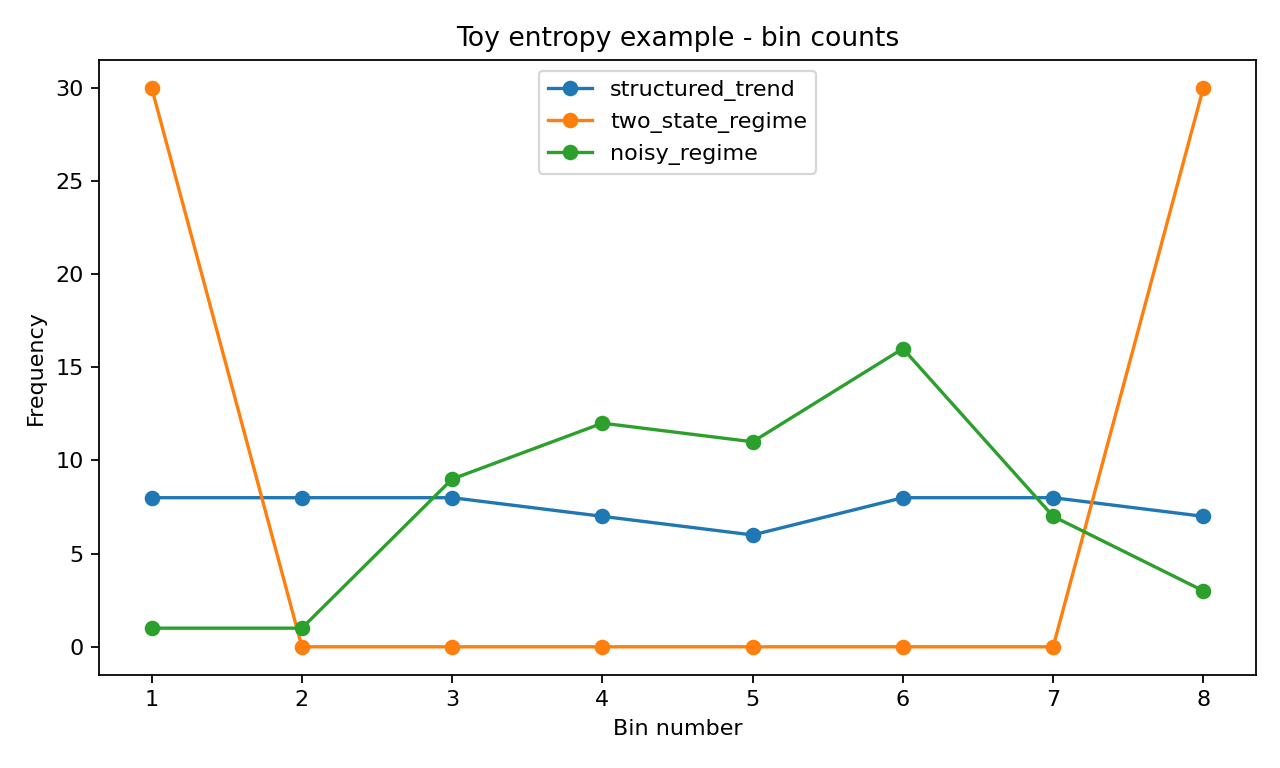

In [10]:
toy_entropy, toy_series_by_name = run_toy_example(output_dir)
plot_toy_entropy_example(toy_series_by_name, output_dir)

print("Toy entropy table")
display(toy_entropy)
display(Image(filename=str(output_dir / "figures" / "figure_01_toy_entropy_example.png"), width=800))

Toy mini-allocation table


,Stock,RollingMean,BullishStateWeight,NeutralStateWeight,BearishEqualWeight
0,A,0.007000,0.6,0.3,0.2
1,B,0.001875,0.0,0.1,0.2
2,C,0.006250,0.4,0.3,0.2
3,D,-0.002125,0.0,0.0,0.2
4,E,0.003500,0.0,0.3,0.2


Toy regime states


,State,AverageEntropy,QLow,QHigh,Phase,Cap
0,State 1,0.43,0.50,0.72,Bullish,0.6
1,State 2,0.58,0.47,0.69,Neutral,0.3


Toy covariance matrix, scaled by 10,000


,A,B,C,D,E
A,0.017243,-0.130000,-0.074286,-0.024286,0.008571
B,-0.130000,2.769921,0.314643,0.359821,-0.130714
C,-0.074286,0.314643,0.547957,0.080357,-0.012857
D,-0.024286,0.359821,0.080357,0.084207,-0.020714
E,0.008571,-0.130714,-0.012857,-0.020714,0.008671


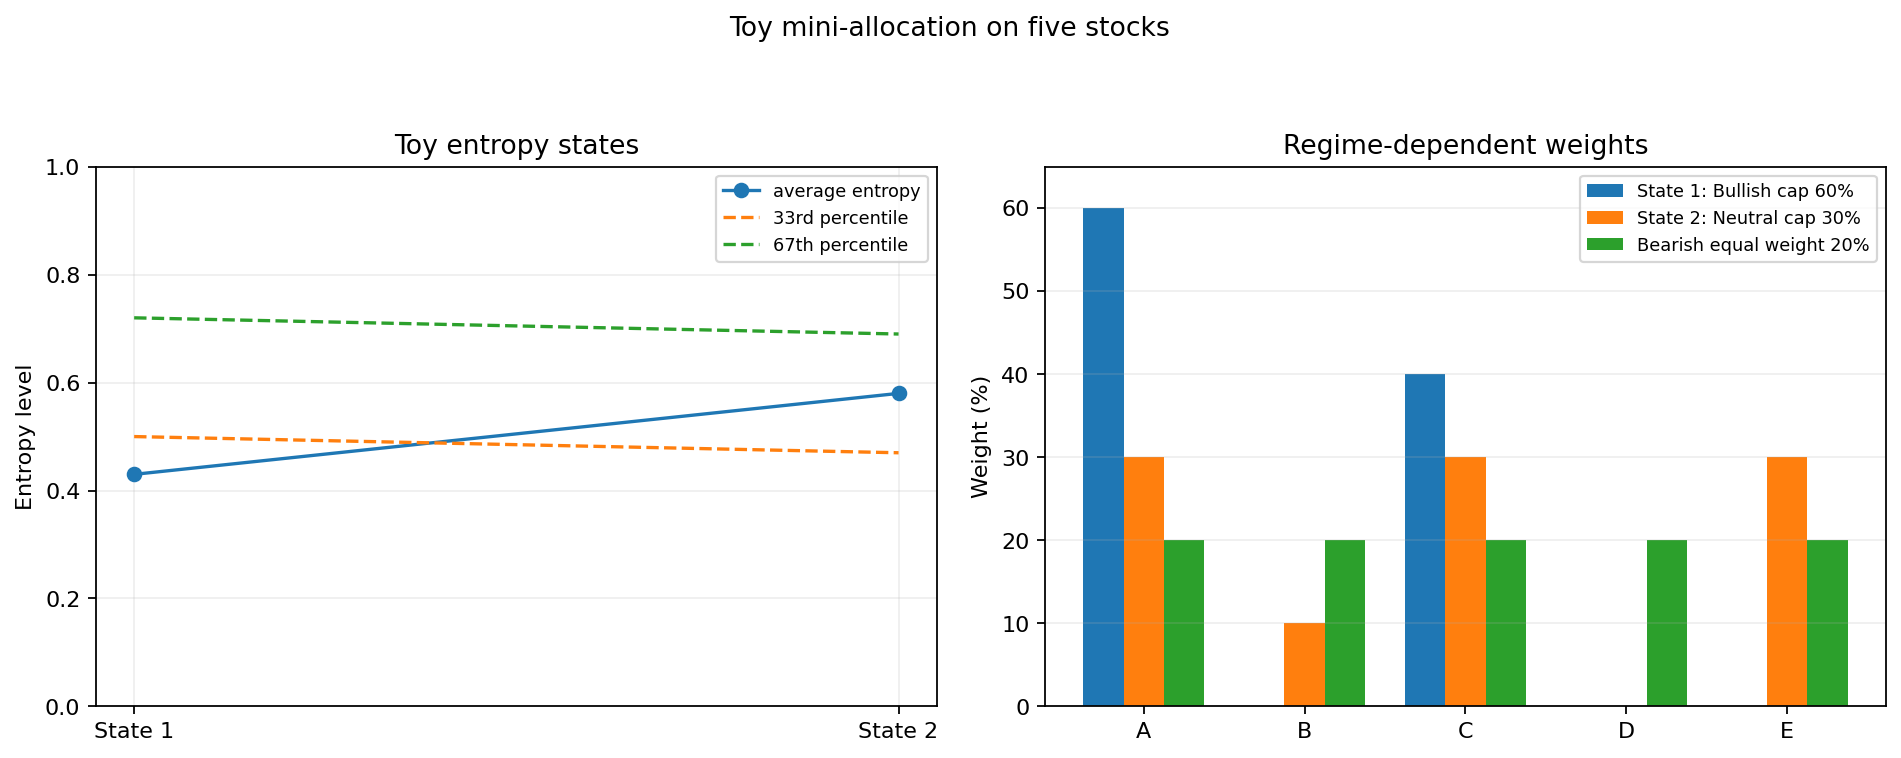

In [11]:
toy_allocation, toy_allocation_data = run_toy_allocation_example(output_dir)
plot_toy_allocation_example(toy_allocation_data, output_dir)

print("Toy mini-allocation table")
display(toy_allocation)

print("Toy regime states")
display(toy_allocation_data["regime_states"])

print("Toy covariance matrix, scaled by 10,000")
display(pd.read_csv(output_dir / "toy_allocation_covariance_x10000.csv", index_col=0))

display(Image(filename=str(output_dir / "figures" / "figure_02_toy_allocation.png"), width=900))

## 7. Full portfolio engine

This section implements the full daily backtest. The algorithm first fills the stock-level rolling windows of length `W = 126`; then it collects `Q = 504` active-universe average-entropy observations to initialize the rolling 33% and 67% entropy thresholds.

No portfolio return, weight, phase, or diagnostic is saved during this warm-up period. The first allocation is produced only when both rolling entropy quantiles are available from past observations. In the provided dataset, this happens on 2003-08-08.

The implementation is causal: the portfolio decision at date `t` uses only the rolling stock states available before observing the return of date `t`. Today's returns are pushed into the rolling states only after the date-`t` portfolio return has been computed.

In [12]:
def run_portfolio_analysis(dataset_path, top10_path):
    """Run the full daily backtest after W and Q warm-up periods."""
    # Load prices and construct return matrices. Cost: O(TN)
    dates, tickers, prices, sp500_prices = load_prices(dataset_path)
    stock_returns = compute_returns(prices)
    sp500_returns = compute_sp500_returns(sp500_prices)

    # Load date -> active top-10 stock indices. Cost: O(TK)
    universe = ActiveUniverse()
    universe.load_from_csv(top10_path)

    # Create one rolling state for each stock. Cost: O(N)
    states = []
    for j in range(len(tickers)):
        states.append(RollingStockState(ROLLING_WINDOW))

    # Rolling quantile structure and output containers.
    entropy_quantiles = RollingQuantile(QUANTILE_WINDOW)
    daily_records = []
    weight_records = []
    diagnostic_records = []

    # Main online loop over trading dates. Cost per day depends on regime.
    for row_index in range(len(dates)):
        date = dates[row_index]
        active_indices = universe.get(date)  # Active top-10 lookup. Cost: O(1) average
        active_ready = len(active_indices) == 10

        # Check whether all active stocks have full rolling windows. Cost: O(K)
        for j in active_indices:
            if not states[j].ready():
                active_ready = False

        if active_ready:
            # Compute entropy for the active top-10. Cost: O(K(W+B))
            entropies = []
            for j in active_indices:
                entropies.append(states[j].rolling_entropy(ENTROPY_BINS))

            average_entropy = sum(entropies) / len(entropies)
            quantiles_ready = entropy_quantiles.ready()

            # Classify the market phase using past rolling quantiles. Cost: O(1)
            if quantiles_ready:
                q_low = entropy_quantiles.quantile(0.33)
                q_high = entropy_quantiles.quantile(0.67)

                if average_entropy <= q_low:
                    phase = "Bullish"
                elif average_entropy >= q_high:
                    phase = "Bearish"
                else:
                    phase = "Neutral"

            # Add today's average entropy after reading the thresholds. Cost: O(Q)
            entropy_quantiles.push(average_entropy)

            if quantiles_ready:
                today_returns = stock_returns[row_index]

                # Extract realized returns of active names. Cost: O(K)
                active_returns = []
                for j in active_indices:
                    active_returns.append(today_returns[j])

                sp500_return = sp500_returns[row_index]
                cap = REGIME_TO_MAX_WEIGHT[phase]

                # Dynamic equal-weight top-10 benchmark. Cost: O(K)
                uniform_weights = np.full(len(active_indices), 1.0 / len(active_indices))
                equal_top10_return = float(np.dot(uniform_weights, np.array(active_returns)))

                if phase == "Bearish":
                    # In Bearish, the 10% cap with K=10 forces equal weight. Cost: O(K)
                    weights = uniform_weights
                    solver_success = True
                    solver_message = "Bearish phase: uniform active allocation; optimizer skipped."
                else:
                    # Build expected returns and covariance, then solve MVO. Cost: O(K + WK^2 + SLSQP)
                    mu = []
                    for j in active_indices:
                        mu.append(states[j].rolling_mean())

                    covariance = covariance_from_states(states, active_indices)

                    weights, solver_success, solver_message = solve_mean_variance_slsqp(
                        mu=np.array(mu, dtype=float),
                        covariance=covariance,
                        cap=cap,
                        risk_aversion=RISK_AVERSION,
                    )

                # Realized strategy return. Cost: O(K)
                entropy_return = float(np.dot(weights, np.array(active_returns)))

                # Save daily strategy and benchmark returns.
                daily_records.append({
                    "Date": date,
                    "Phase": phase,
                    "AverageEntropy": average_entropy,
                    "QLow": q_low,
                    "QHigh": q_high,
                    "Cap": cap,
                    "EntropyMVO": entropy_return,
                    "EqualWeightTop10": equal_top10_return,
                    "SP500": sp500_return,
                    "SolverSuccess": solver_success,
                })

                # Save feasibility and solver diagnostics.
                diagnostic_records.append({
                    "Date": date,
                    "Phase": phase,
                    "Cap": cap,
                    "SolverSuccess": solver_success,
                    "SolverMessage": str(solver_message),
                    "WeightSum": float(np.sum(weights)),
                    "MaxWeight": float(np.max(weights)),
                    "MinWeight": float(np.min(weights)),
                    "ActiveNames": len(active_indices),
                })

                # Save ticker-level weights for the heatmap and exports. Cost: O(K)
                for local_index in range(len(active_indices)):
                    stock_index = active_indices[local_index]
                    weight_records.append({
                        "Date": date,
                        "Ticker": tickers[stock_index],
                        "StockIndex": stock_index,
                        "Phase": phase,
                        "EntropyMVOWeight": float(weights[local_index]),
                        "EqualWeightTop10Weight": float(uniform_weights[local_index]),
                    })

        # Push today's returns only after the date-t decision. Cost: O(N)
        today_returns = stock_returns[row_index]
        for j in range(len(tickers)):
            states[j].push(today_returns[j])

    # Convert output records to DataFrames. Cost: O(TK) overall because weights are ticker-level.
    daily = pd.DataFrame(daily_records)
    daily["Date"] = pd.to_datetime(daily["Date"])

    weights = pd.DataFrame(weight_records)
    weights["Date"] = pd.to_datetime(weights["Date"])

    diagnostics = pd.DataFrame(diagnostic_records)
    diagnostics["Date"] = pd.to_datetime(diagnostics["Date"])

    return daily, weights, diagnostics

In [13]:
daily, weights, diagnostics = run_portfolio_analysis(dataset_path, top10_path)

print("Return-window warm-up W:", ROLLING_WINDOW)
print("Entropy-quantile warm-up Q:", QUANTILE_WINDOW)
print("First portfolio date:", daily["Date"].min().date())
print("Last portfolio date:", daily["Date"].max().date())
print("Daily return rows:", daily.shape)
print("Weight rows:", weights.shape)
print("Diagnostic rows:", diagnostics.shape)

display(daily.head())
display(weights.head())
display(diagnostics.head())


Return-window warm-up W: 126
Entropy-quantile warm-up Q: 504
First portfolio date: 2003-08-08
Last portfolio date: 2024-12-31
Daily return rows: (5382, 10)
Weight rows: (53820, 6)
Diagnostic rows: (5382, 9)


,Date,Phase,AverageEntropy,QLow,QHigh,Cap,EntropyMVO,EqualWeightTop10,SP500,SolverSuccess
0,2003-08-08,Bearish,0.838984,0.756983,0.805727,0.1,0.001114,0.001114,0.003571,True
1,2003-08-11,Bearish,0.837835,0.756983,0.806543,0.1,0.003559,0.003559,0.003323,True
2,2003-08-12,Bearish,0.837790,0.756983,0.807237,0.1,0.007255,0.007255,0.009964,True
3,2003-08-13,Bearish,0.837684,0.756983,0.807327,0.1,-0.008981,-0.008981,-0.006003,True
4,2003-08-14,Bearish,0.836350,0.756983,0.807403,0.1,0.005939,0.005939,0.006590,True


,Date,Ticker,StockIndex,Phase,EntropyMVOWeight,EqualWeightTop10Weight
0,2003-08-08,GE,9,Bearish,0.1,0.1
1,2003-08-08,MSFT,20,Bearish,0.1,0.1
2,2003-08-08,PFE,22,Bearish,0.1,0.1
3,2003-08-08,WMT,30,Bearish,0.1,0.1
4,2003-08-08,XOM,31,Bearish,0.1,0.1


,Date,Phase,Cap,SolverSuccess,SolverMessage,WeightSum,MaxWeight,MinWeight,ActiveNames
0,2003-08-08,Bearish,0.1,True,Bearish phase: uniform active allocation; opti...,1.0,0.1,0.1,10
1,2003-08-11,Bearish,0.1,True,Bearish phase: uniform active allocation; opti...,1.0,0.1,0.1,10
2,2003-08-12,Bearish,0.1,True,Bearish phase: uniform active allocation; opti...,1.0,0.1,0.1,10
3,2003-08-13,Bearish,0.1,True,Bearish phase: uniform active allocation; opti...,1.0,0.1,0.1,10
4,2003-08-14,Bearish,0.1,True,Bearish phase: uniform active allocation; opti...,1.0,0.1,0.1,10


## 8. Metrics and summaries

These functions create the performance table, wealth and drawdown curves, phase counts, transition matrix, and crisis-window analysis used by the report.


In [14]:
def annualized_return(returns, trading_days=252):
    """Convert a daily return series into compounded annualized return. Cost: O(T)."""
    clean = returns.dropna()
    wealth = float((1.0 + clean).prod())
    return wealth ** (trading_days / len(clean)) - 1.0


def annualized_volatility(returns, trading_days=252):
    """Compute annualized volatility from daily returns. Cost: O(T)."""
    clean = returns.dropna()
    return float(clean.std(ddof=1) * math.sqrt(trading_days))


def sharpe_ratio(returns):
    """Compute the zero-risk-rate Sharpe ratio used in the report tables. Cost: O(T)."""
    volatility = annualized_volatility(returns)
    if volatility == 0 or np.isnan(volatility):
        return np.nan
    return annualized_return(returns) / volatility


def max_drawdown(returns):
    """Compute the maximum drawdown of a compounded wealth path. Cost: O(T)."""
    clean = returns.dropna()
    wealth = (1.0 + clean).cumprod()
    drawdown = wealth / wealth.cummax() - 1.0
    return float(drawdown.min())


def performance_table(daily):
    """Create the full-sample performance table for strategy and benchmarks. Cost: O(T)."""
    strategies = [
        ("EntropyMVO", "Entropy market-phase MVO"),
        ("EqualWeightTop10", "Equal-weight top-10 benchmark"),
        ("SP500", "S&P 500 benchmark"),
    ]
    rows = []

    for column, label in strategies:
        returns = daily[column]
        rows.append({
            "Strategy": label,
            "Observations": int(returns.dropna().shape[0]),
            "AnnualizedReturn": annualized_return(returns),
            "AnnualizedVolatility": annualized_volatility(returns),
            "Sharpe": sharpe_ratio(returns),
            "MaxDrawdown": max_drawdown(returns),
            "FinalWealth": float((1.0 + returns.dropna()).prod()),
        })

    return pd.DataFrame(rows)


def wealth_curves(daily):
    """Build cumulative wealth curves for the three reported return columns. Cost: O(T)."""
    wealth = pd.DataFrame()
    wealth["Date"] = daily["Date"]

    for column in ["EntropyMVO", "EqualWeightTop10", "SP500"]:
        wealth[column] = (1.0 + daily[column]).cumprod()

    return wealth


def drawdown_curves(daily):
    """Build drawdown curves for the three reported return columns. Cost: O(T)."""
    drawdown = pd.DataFrame()
    drawdown["Date"] = daily["Date"]

    for column in ["EntropyMVO", "EqualWeightTop10", "SP500"]:
        wealth = (1.0 + daily[column]).cumprod()
        drawdown[column] = wealth / wealth.cummax() - 1.0

    return drawdown


def phase_summary(daily):
    """Summarize market-phase counts, shares, entropy, and mean strategy return. Cost: O(T)."""
    phase_counts = Counter(daily["Phase"].tolist())
    rows = []

    for phase in ["Bullish", "Neutral", "Bearish"]:
        phase_rows = daily.loc[daily["Phase"] == phase]
        rows.append({
            "Phase": phase,
            "Days": phase_counts.get(phase, 0),
            "Share": phase_counts.get(phase, 0) / len(daily),
            "AverageEntropy": phase_rows["AverageEntropy"].mean(),
            "MeanEntropyMVOReturn": phase_rows["EntropyMVO"].mean(),
        })

    return pd.DataFrame(rows)


def transition_matrix(daily):
    """Count and normalize one-day transitions between entropy regimes. Cost: O(T)."""
    phases = ["Bullish", "Neutral", "Bearish"]
    counts = pd.DataFrame(0, index=phases, columns=phases, dtype=int)
    phase_list = daily["Phase"].tolist()

    for i in range(len(phase_list) - 1):
        current_phase = phase_list[i]
        next_phase = phase_list[i + 1]
        if current_phase in phases and next_phase in phases:
            counts.loc[current_phase, next_phase] += 1

    probabilities = counts.div(counts.sum(axis=1), axis=0)
    return counts, probabilities


def crisis_analysis(daily):
    """Evaluate local performance inside the four crisis windows. Cost: O(CT)."""
    rows = []

    for name, start, end in CRISIS_WINDOWS:
        mask = (daily["Date"] >= start) & (daily["Date"] <= end)
        window = daily.loc[mask].copy()

        for strategy in ["EntropyMVO", "EqualWeightTop10", "SP500"]:
            returns = window[strategy]
            rows.append({
                "Crisis": name,
                "Start": start,
                "End": end,
                "Strategy": strategy,
                "Observations": int(returns.dropna().shape[0]),
                "CumulativeReturn": float((1.0 + returns.dropna()).prod() - 1.0),
                "AnnualizedReturn": annualized_return(returns),
                "AnnualizedVolatility": annualized_volatility(returns),
                "Sharpe": sharpe_ratio(returns),
                "MaxDrawdown": max_drawdown(returns),
            })

    return pd.DataFrame(rows)

In [15]:
metrics = performance_table(daily)
phases = phase_summary(daily)
transition_counts, transition_probs = transition_matrix(daily)
crisis_stats = crisis_analysis(daily)

print("Performance metrics")
display(metrics)
print("Phase summary")
display(phases)
print("Transition probabilities")
display(transition_probs.round(4))
print("Crisis-window analysis")
display(crisis_stats)


Performance metrics


,Strategy,Observations,AnnualizedReturn,AnnualizedVolatility,Sharpe,MaxDrawdown,FinalWealth
0,Entropy market-phase MVO,5382,0.140462,0.200790,0.699545,-0.489947,16.560805
1,Equal-weight top-10 benchmark,5382,0.114968,0.194022,0.592551,-0.515424,10.218515
2,S&P 500 benchmark,5382,0.109762,0.187607,0.585064,-0.547991,9.246613


Phase summary


,Phase,Days,Share,AverageEntropy,MeanEntropyMVOReturn
0,Bullish,2084,0.387217,0.707607,0.000693
1,Neutral,1634,0.303605,0.751880,0.000750
2,Bearish,1664,0.309179,0.780000,0.000342


Transition probabilities


,Bullish,Neutral,Bearish
Bullish,0.9525,0.0461,0.0014
Neutral,0.0582,0.8726,0.0692
Bearish,0.0024,0.0679,0.9297


Crisis-window analysis


,Crisis,Start,End,Strategy,Observations,CumulativeReturn,AnnualizedReturn,AnnualizedVolatility,Sharpe,MaxDrawdown
0,Global financial crisis,2007-10-09,2009-03-09,EntropyMVO,355,-0.473392,-0.365699,0.302427,-1.209216,-0.489947
1,Global financial crisis,2007-10-09,2009-03-09,EqualWeightTop10,355,-0.507983,-0.395566,0.352712,-1.121498,-0.515424
2,Global financial crisis,2007-10-09,2009-03-09,SP500,355,-0.544322,-0.427606,0.380077,-1.125051,-0.547991
3,Euro debt and US downgrade,2011-07-01,2011-12-31,EntropyMVO,127,0.015997,0.031991,0.215081,0.148740,-0.119399
4,Euro debt and US downgrade,2011-07-01,2011-12-31,EqualWeightTop10,127,0.038582,0.078010,0.242797,0.321298,-0.131032
5,Euro debt and US downgrade,2011-07-01,2011-12-31,SP500,127,-0.036903,-0.071896,0.302870,-0.237381,-0.183770
6,COVID crash,2020-02-19,2020-04-30,EntropyMVO,51,-0.083750,-0.350912,0.623249,-0.563036,-0.258518
7,COVID crash,2020-02-19,2020-04-30,EqualWeightTop10,51,-0.088383,-0.366968,0.633870,-0.578933,-0.277983
8,COVID crash,2020-02-19,2020-04-30,SP500,51,-0.132549,-0.504711,0.679136,-0.743167,-0.337904
9,Inflation and rates bear market,2022-01-03,2022-12-30,EntropyMVO,251,-0.338086,-0.339173,0.301222,-1.125991,-0.363502


## 9. Save outputs and generate figures

This block writes the CSV outputs and the non-duplicated figure set. The standalone entropy-quantile plot is omitted because the colored market-phase diagnostic already contains the entropy bands with richer context.


In [16]:
def save_outputs(daily, weights, diagnostics, output_dir):
    """Save all CSV outputs and dispatch figure generation."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    metrics = performance_table(daily)
    phases = phase_summary(daily)
    transition_counts, transition_probs = transition_matrix(daily)
    crisis_stats = crisis_analysis(daily)

    daily.to_csv(output_dir / "daily_portfolio_returns.csv", index=False)
    wealth_curves(daily).to_csv(output_dir / "wealth_curves.csv", index=False)
    drawdown_curves(daily).to_csv(output_dir / "drawdown_curves.csv", index=False)
    weights.to_csv(output_dir / "weights_long.csv", index=False)
    diagnostics.to_csv(output_dir / "diagnostics.csv", index=False)
    metrics.to_csv(output_dir / "performance_metrics.csv", index=False)
    phases.to_csv(output_dir / "phase_summary.csv", index=False)
    transition_counts.to_csv(output_dir / "transition_counts.csv")
    transition_probs.round(4).to_csv(output_dir / "transition_probabilities_4dp.csv")
    crisis_stats.to_csv(output_dir / "crisis_analysis.csv", index=False)

    save_figures(daily, weights, metrics, phases, transition_probs, crisis_stats, output_dir)

    return metrics, phases, transition_probs, crisis_stats


def save_figures(daily, weights, metrics, phase_stats, transition_probs, crisis_stats, output_dir):
    """Generate the final non-duplicated report figure set."""
    figure_dir = Path(output_dir) / "figures"
    figure_dir.mkdir(parents=True, exist_ok=True)

    for path in figure_dir.glob("figure_*.png"):
        if path.name not in {"figure_01_toy_entropy_example.png", "figure_02_toy_allocation.png"}:
            path.unlink()

    wealth = wealth_curves(daily)
    drawdowns = drawdown_curves(daily)
    strategy_columns = ["EntropyMVO", "EqualWeightTop10", "SP500"]
    strategy_labels = ["Entropy market-phase MVO", "Equal-weight top-10", "S&P 500 benchmark"]

    # Figure 3.
    plt.figure(figsize=(10, 5))
    for column_index in range(len(strategy_columns)):
        column = strategy_columns[column_index]
        label = strategy_labels[column_index]
        plt.plot(wealth["Date"], wealth[column], label=label)

    plt.title("Cumulative wealth")
    plt.xlabel("Date")
    plt.ylabel("Wealth")
    plt.legend()
    plt.tight_layout()
    plt.savefig(figure_dir / "figure_03_cumulative_wealth.png", dpi=160)
    plt.close()

    # Figure 4.
    plt.figure(figsize=(10, 5))
    for column_index in range(len(strategy_columns)):
        column = strategy_columns[column_index]
        label = strategy_labels[column_index]
        plt.plot(drawdowns["Date"], drawdowns[column], label=label)

    plt.title("Drawdown curves")
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.legend()
    plt.tight_layout()
    plt.savefig(figure_dir / "figure_04_drawdown_curves.png", dpi=160)
    plt.close()

    # Figure 6.
    plot_crisis_behavior(daily, figure_dir)

    # Figure 7.
    plt.figure(figsize=(7, 4.8))
    colors = []

    for phase in phase_stats["Phase"]:
        colors.append(MARKET_PHASE_COLORS.get(phase, "#969696"))

    plt.bar(phase_stats["Phase"], phase_stats["Days"], color=colors)
    plt.title("Market phase counts")
    plt.xlabel("Phase")
    plt.ylabel("Days")
    plt.tight_layout()
    plt.savefig(figure_dir / "figure_07_phase_counts.png", dpi=160)
    plt.close()

    # Figure 8.
    plot_market_phase_diagnostics(daily, figure_dir)

    # Figure 9.
    plot_transition_matrix(transition_probs, figure_dir)

    # Figure 10.
    weight_pivot = weights.pivot_table(
        index="Date",
        columns="Ticker",
        values="EntropyMVOWeight",
        aggfunc="sum",
    ).fillna(0.0)

    if len(weight_pivot) > 500:
        step = int(math.ceil(len(weight_pivot) / 500))
        weight_plot = weight_pivot.iloc[::step]
    else:
        weight_plot = weight_pivot

    plt.figure(figsize=(12, 5.5))
    plt.imshow(weight_plot.T.values, aspect="auto")
    plt.yticks(range(len(weight_plot.columns)), weight_plot.columns)

    date_positions = []
    date_labels = []
    tick_count = min(8, len(weight_plot.index))
    positions = np.linspace(0, len(weight_plot.index) - 1, tick_count).astype(int)

    for position in positions:
        date_positions.append(position)
        date_labels.append(str(weight_plot.index[position].date()))

    plt.xticks(date_positions, date_labels, rotation=25, ha="right")
    plt.title("Entropy MVO weights heatmap")
    plt.xlabel("Date")
    plt.ylabel("Ticker")
    plt.colorbar(label="Weight")
    plt.tight_layout()
    plt.savefig(figure_dir / "figure_10_entropy_mvo_weights_heatmap.png", dpi=160)
    plt.close()


def crisis_legend_label(label, returns_series):
    """Build compact legend text with only cumulative crisis return."""
    clean = returns_series.dropna()

    if len(clean) == 0:
        return label

    cumulative_return = float((1.0 + clean).prod() - 1.0)

    return f"{label} ({cumulative_return:.1%})"


def shade_market_phases(ax, daily):
    """Shade a Matplotlib axis according to contiguous entropy-regime blocks."""
    phase_data = daily[["Date", "Phase"]].copy()
    phase_data = phase_data.dropna().sort_values("Date")

    if len(phase_data) == 0:
        return []

    segment_id = phase_data["Phase"].ne(phase_data["Phase"].shift()).cumsum()

    for segment in segment_id.unique():
        block = phase_data.loc[segment_id == segment]
        phase = str(block["Phase"].iloc[0])
        color = MARKET_PHASE_COLORS.get(phase, "#bdbdbd")
        start = block["Date"].iloc[0]
        end = block["Date"].iloc[-1] + pd.Timedelta(days=1)

        ax.axvspan(
            start,
            end,
            color=color,
            alpha=0.11,
            linewidth=0,
            zorder=0,
        )

    patches = []

    for phase in MARKET_PHASE_ORDER:
        if phase in set(phase_data["Phase"]):
            patches.append(
                Patch(
                    facecolor=MARKET_PHASE_COLORS[phase],
                    alpha=0.20,
                    label=phase,
                )
            )

    return patches


def plot_crisis_behavior(daily, figure_dir):
    """Plot crisis-window wealth with Bullish/Neutral/Bearish phase shading."""
    import matplotlib.dates as mdates

    labels = {
        "EntropyMVO": "Entropy MVO",
        "EqualWeightTop10": "Equal weight",
        "SP500": "S&P 500",
    }

    fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.2))
    phase_legend_patches = []

    for ax, window_info in zip(axes.ravel(), CRISIS_WINDOWS):
        name, start, end = window_info

        start = pd.to_datetime(start)
        end = pd.to_datetime(end)

        mask = (daily["Date"] >= start) & (daily["Date"] <= end)
        block = daily.loc[mask].copy()

        if len(block) == 0:
            ax.set_visible(False)
            continue

        # Add Bullish / Neutral / Bearish background colors.
        patches = shade_market_phases(ax, block)

        if len(phase_legend_patches) == 0:
            phase_legend_patches = patches

        for column in ["EntropyMVO", "EqualWeightTop10", "SP500"]:
            wealth = (1.0 + block[column].fillna(0.0)).cumprod()
            wealth = wealth / wealth.iloc[0]

            ax.plot(
                block["Date"],
                wealth,
                linewidth=1.25,
                label=crisis_legend_label(labels[column], block[column]),
            )

        phase_shares = (
            block["Phase"]
            .value_counts(normalize=True)
            .reindex(MARKET_PHASE_ORDER)
            .fillna(0.0)
        )

        phase_text = (
            f"Bullish {phase_shares['Bullish']:.0%} | "
            f"Neutral {phase_shares['Neutral']:.0%} | "
            f"Bearish {phase_shares['Bearish']:.0%}"
        )

        ax.text(
            0.01,
            0.03,
            phase_text,
            transform=ax.transAxes,
            fontsize=6.6,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"),
        )

        ax.set_title(name, fontsize=10)
        ax.set_ylabel("Rebased wealth")
        ax.grid(alpha=0.25)

        locator = mdates.AutoDateLocator(maxticks=4)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
        ax.tick_params(axis="x", labelsize=7, rotation=15)
        ax.legend(fontsize=6.6, frameon=True, framealpha=0.88)

    if len(phase_legend_patches) > 0:
        fig.legend(
            handles=phase_legend_patches,
            loc="lower center",
            ncol=3,
            fontsize=8,
            frameon=False,
        )

    fig.suptitle(
        "Crisis-period behaviour, wealth rebased at each crisis start",
        y=0.99,
    )
    fig.tight_layout(rect=[0, 0.04, 1, 0.97])
    fig.savefig(figure_dir / "figure_06_crisis_behavior.png", dpi=160)
    plt.close(fig)


def plot_market_phase_diagnostics(daily, figure_dir):
    """Create Figure 8 with entropy bands and phase labels only."""
    plot_data = daily.copy()

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(10.5, 5.4),
        sharex=True,
        gridspec_kw={"height_ratios": [1.4, 0.3]},
    )

    legend_patches = shade_market_phases(axes[0], plot_data)

    axes[0].fill_between(
        plot_data["Date"],
        plot_data["QLow"],
        plot_data["QHigh"],
        color="tab:gray",
        alpha=0.14,
        label="Neutral band",
    )

    axes[0].plot(
        plot_data["Date"],
        plot_data["AverageEntropy"],
        linewidth=1.1,
        color="black",
        label="Average entropy",
    )

    axes[0].plot(
        plot_data["Date"],
        plot_data["QLow"],
        linewidth=0.9,
        color=MARKET_PHASE_COLORS["Bullish"],
        linestyle="--",
        label="Rolling 33%",
    )

    axes[0].plot(
        plot_data["Date"],
        plot_data["QHigh"],
        linewidth=0.9,
        color=MARKET_PHASE_COLORS["Bearish"],
        linestyle="--",
        label="Rolling 67%",
    )

    axes[0].set_ylim(0.4, 1.0)
    axes[0].set_ylabel("Normalized entropy")
    axes[0].grid(alpha=0.25)

    if len(legend_patches) > 0:
        phase_legend = axes[0].legend(
            handles=legend_patches,
            ncol=3,
            fontsize=8,
            loc="upper left",
        )
        axes[0].add_artist(phase_legend)

    axes[0].legend(fontsize=8, loc="lower left", ncol=2)

    phase_numbers = {}

    for i in range(len(MARKET_PHASE_ORDER)):
        phase_numbers[MARKET_PHASE_ORDER[i]] = i

    y_values = []
    colors = []

    for phase in plot_data["Phase"]:
        y_values.append(phase_numbers.get(phase, 0))
        colors.append(MARKET_PHASE_COLORS.get(phase, "#bdbdbd"))

    axes[1].scatter(
        plot_data["Date"],
        y_values,
        c=colors,
        s=4,
        marker="s",
    )

    axes[1].set_yticks(list(phase_numbers.values()))
    axes[1].set_yticklabels(MARKET_PHASE_ORDER, fontsize=7)
    axes[1].set_xlabel("Date")
    axes[1].grid(alpha=0.15, axis="x")

    fig.suptitle("Market phase diagnostics from rolling entropy quantiles", y=0.99)
    fig.tight_layout()
    fig.savefig(figure_dir / "figure_08_market_phase_diagnostics.png", dpi=160)
    plt.close(fig)


def plot_transition_matrix(transition_probs, figure_dir):
    """Plot the entropy-regime transition probability matrix."""
    matrix = transition_probs.reindex(index=MARKET_PHASE_ORDER, columns=MARKET_PHASE_ORDER)
    values = matrix.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(5.4, 4.6))
    image = ax.imshow(values, cmap="Blues", vmin=0.0, vmax=1.0)

    ax.set_xticks(range(len(MARKET_PHASE_ORDER)))
    ax.set_xticklabels(MARKET_PHASE_ORDER)
    ax.set_yticks(range(len(MARKET_PHASE_ORDER)))
    ax.set_yticklabels(MARKET_PHASE_ORDER)
    ax.set_xlabel("To phase (t+1)")
    ax.set_ylabel("From phase (t)")

    for i in range(len(MARKET_PHASE_ORDER)):
        for j in range(len(MARKET_PHASE_ORDER)):
            value = values[i, j]

            if np.isfinite(value):
                if value >= 0.6:
                    text_color = "white"
                else:
                    text_color = "black"

                ax.text(
                    j,
                    i,
                    f"{value:.4f}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=9,
                )

    ax.set_title("Entropy regime transition matrix")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(figure_dir / "figure_09_transition_matrix.png", dpi=160)
    plt.close(fig)

In [17]:
metrics, phases, transition_probs, crisis_stats = save_outputs(daily, weights, diagnostics, output_dir)

print("Saved CSV outputs in", output_dir)
print("Saved figures in", output_dir / "figures")
print("Available report figure files:")
for path in sorted((output_dir / "figures").glob("figure_*.png")):
    print(path.name)


Saved CSV outputs in C:\Users\salvm\Desktop\GitHub\Entropy\FINALE\outputs
Saved figures in C:\Users\salvm\Desktop\GitHub\Entropy\FINALE\outputs\figures
Available report figure files:
figure_01_toy_entropy_example.png
figure_02_toy_allocation.png
figure_03_cumulative_wealth.png
figure_04_drawdown_curves.png
figure_06_crisis_behavior.png
figure_07_phase_counts.png
figure_08_market_phase_diagnostics.png
figure_09_transition_matrix.png
figure_10_entropy_mvo_weights_heatmap.png
